# Final Data Preparation — TD–GC–MS (QC + Samples)

**Purpose**  
Prepare GC–MS peak tables for downstream analytics by cleaning QC/sample data, checking QC performance, correcting instrument drift, and producing normalized outputs.

**What this notebook does (high level)**  
- Loads input paths and parameters from a YAML config (Databricks/UC volumes).
- Cleans QC tables and prepares sample tables (retention time handling + ID filtering).
- Matches alkane standards to peak IDs to identify **stable peaks**.
- Merges QC peak intensities with master metadata to recover injection order / QC levels.
- Evaluates QC linearity and injection stability (LOESS + linear regression diagnostics).
- Applies **global LOESS drift correction** using stable peaks.
- Ranks QC runs based on corrected intensities.
- Normalizes samples using the QC4 mean reference and returns **wide + long** normalized datasets.



In [0]:
%pip install -U openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import matplotlib; matplotlib.use('inline')
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import subprocess; subprocess.check_call(["python", "-m", "pip", "install", "networkx"])  
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess
import yaml
import os, importlib.util
import subprocess; subprocess.check_call(["python", "-m", "pip", "install", "dash"]); import dash


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Load QC data using path from config

In [0]:


CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

txt = "\n".join([r["value"] for r in spark.read.text(CONFIG_PATH).collect()])
config = yaml.safe_load(txt)

print("config keys:", list(config.keys()))


config keys: ['paths', 'qc', 'sample', 'data_paths', 'parameters', 'settings', 'data']


In [0]:
import sys
sys.path.append("/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project")

import data_prepration as dp


# Load and clean QCs

In [0]:
%pip install openpyxl
import pandas as pd

qc_cfg = config["qc"]
qc_input_path = qc_cfg["input_file_american"]
qc_output_path = qc_cfg["output_file_american"]

qc_data_mixed = pd.read_excel(
    qc_input_path,
    sheet_name=qc_cfg["sheet_name"],
    header=qc_cfg["header_row"],
    engine="openpyxl"
)
import os

os.makedirs(os.path.dirname(qc_output_path), exist_ok=True)
cleaned_qc_mixed, t1_cols = dp.clean_qc_data(
    qc_data_mixed,
    save_path=qc_output_path
)

print("QC saved to:", qc_output_path)
display(cleaned_qc_mixed.head())

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
 Extracted T1 columns: 20
Filtered DataFrame shape: (324, 25)
Mean |avg(tR1,tR2) - tR|: 0.000247
Max  |avg(tR1,tR2) - tR|: 0.000500
 Cleaned QC data saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/cleaned_qc_mixed.csv
QC saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american/cleaned_qc_mixed.csv


Peak,tR_best,m/z,s1 KW25_QC1_B1_D1_T1,s2 KW25_QC1_B1_D2_T1,s3 KW25_QC1_B1_D3_T1,s4 KW25_QC1_B1_D4_T1,s5 KW25_QC1_B1_D5_T1,s6 KW25_QC2_B1_D1_T1,s7 KW25_QC2_B1_D2_T1,s8 KW25_QC2_B1_D3_T1,s9 KW25_QC2_B1_D4_T1,s10 KW25_QC2_B1_D5_T1,s11 KW25_QC3_B1_D1_T1,s12 KW25_QC3_B1_D2_T1,s13 KW25_QC3_B1_D3_T1,s14 KW25_QC3_B1_D4_T1,s15 KW25_QC3_B1_D5_T1,s16 KW25_QC4_B1_D1_T1,s17 KW25_QC4_B1_D2_T1,s18 KW25_QC4_B1_D3_T1,s19 KW25_QC4_B1_D4_T1,s20 KW25_QC4_B1_D5_T1
1,1.9209999999999998,40,16880,41808,41904,35576,33760,16880,16880,38952,16880,32512,42856,16880,40600,40784,34192,45536,46192,42504,35584,38120
2,1.9555,85,6191,6960,4467,6865,6400,13533,6211,4756,4888,8771,14922,29129,6731,32416,56742,14047,11779,4694,18069,48510
3,1.9935,44,288514,666896,583497,541658,602873,324306,607995,285750,546778,531523,939096,1150492,678028,1026224,1182224,1057918,791257,540991,821053,960073
4,2.0415,64,235587,210436,175233,141041,185276,264351,222260,160556,117492,180673,183017,273920,166424,150703,226449,293662,226199,132310,170117,291430
5,2.1055,157,11688,10798,8306,11615,13047,105931,18481,41237,6748,15241,19850,67833,7219,20098,17697,28414,10429,19441,17634,107039


# Data prepration module importing

In [0]:
import importlib.util
import sys
import os

DP_PATH = "/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py"

assert os.path.exists(DP_PATH), f" data_preparation.py not found: {DP_PATH}"

spec = importlib.util.spec_from_file_location("data_preparation", DP_PATH)
dp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dp)

print(" data_preparation loaded from:", DP_PATH)
print("Functions:", [f for f in dir(dp) if not f.startswith("_")])


 data_preparation loaded from: /Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py
Functions: ['Counter', 'Dash', 'Input', 'LinearRegression', 'Output', 'analyze_qc_intensity_stability', 'assess_stable_peak_injection_order_trend', 'average_gcms_intensities_by_variety', 'clean_qc_data', 'dcc', 'global_drift_correction', 'go', 'html', 'linregress', 'load_sample_data', 'lowess', 'make_subplots', 'match_alkanes_to_peaks', 'merge_qc_peak_intensities_with_metadata', 'normalize_with_qc4_meaned_samples', 'np', 'pd', 'plot_alkane_matches', 'plot_injection_stability_loess', 'plot_qc_injection_stability_linear', 'plt', 'prepare_and_clean_potato_data', 'rank_qcs', 're', 'run_qc_trend_dashboard', 'sns']


# Load sample 

In [0]:
import os

# =========================================================
# 1) READ FROM CONFIG (NO HARDCODE)
# =========================================================
sample_cfg = config["sample"]
data_cfg   = config["data_paths"]

input_path = sample_cfg["input_file_american"]


sample_rows = sample_cfg.get("header_row", 50)

assert os.path.exists(input_path), f"Sample input not found: {input_path}"

# =========================================================
# 2) SAFETY CHECK
# =========================================================
if not hasattr(dp, "load_sample_data"):
    raise AttributeError("data_preparation.py has no function named load_sample_data")

# =========================================================
# 3) CALL FUNCTION (MATCHES MODULE SIGNATURE)
# =========================================================
sample_data, header_row_detected = dp.load_sample_data(
    input_path=input_path,
    sample_rows=sample_rows
)

print("Header row detected:", header_row_detected)
print("Sample data shape:", sample_data.shape)
display(sample_data.head())


 Header row taken from config: 12


,Peak,tR1,tR2,tR,m/z,ID Names,s1 KW25_10_B1_D1_T1,s2 KW25_10_B1_D1_T2,s3 KW25_11_B1_D1_T1,s4 KW25_11_B1_D1_T2,s5 KW25_12_B1_D1_T1,s6 KW25_12_B1_D1_T2,s7 KW25_13_B1_D2_T1,s8 KW25_13_B1_D2_T2,s9 KW25_14_B1_D2_T1,s10 KW25_14_B1_D2_T2,s11 KW25_15_B1_D2_T1,s12 KW25_15_B1_D2_T2,s13 KW25_16_B1_D2_T1,s14 KW25_16_B1_D2_T2,s15 KW25_17_B1_D2_T1,s16 KW25_17_B1_D2_T2,s17 KW25_18_B1_D2_T1,s18 KW25_18_B1_D2_T2,s19 KW25_19_B1_D2_T1,s20 KW25_19_B1_D2_T2,s21 KW25_1_B1_D1_T1,s22 KW25_1_B1_D1_T2,s23 KW25_20_B1_D2_T1,s24 KW25_20_B1_D2_T2,s25 KW25_21_B1_D2_T1,s26 KW25_21_B1_D2_T2,s27 KW25_22_B1_D2_T1,s28 KW25_22_B1_D2_T2,s29 KW25_23_B1_D2_T1,s30 KW25_23_B1_D2_T2,s31 KW25_24_B1_D2_T1,s32 KW25_24_B1_D2_T2,s33 KW25_25_B1_D3_T1,s34 KW25_25_B1_D3_T2,...,s74 KW25_44_B1_D4_T1,s75 KW25_44_B1_D4_T2,s76 KW25_45_B1_D4_T1,s77 KW25_45_B1_D4_T2,s78 KW25_46_B1_D4_T1,s79 KW25_46_B1_D4_T2,s80 KW25_47_B1_D4_T1,s81 KW25_47_B1_D4_T2,s82 KW25_48_B1_D4_T1,s83 KW25_48_B1_D4_T2,s84 KW25_49_B1_D5_T1,s85 KW25_49_B1_D5_T2,s86 KW25_4_B1_D1_T1,s87 KW25_4_B1_D1_T2,s88 KW25_50_B1_D5_T1,s89 KW25_50_B1_D5_T2,s90 KW25_51_B1_D5_T1,s91 KW25_51_B1_D5_T2,s92 KW25_52_B1_D5_T1,s93 KW25_52_B1_D5_T2,s94 KW25_53_B1_D5_T1,s95 KW25_53_B1_D5_T2,s96 KW25_54_B1_D5_T1,s97 KW25_54_B1_D5_T2,s98 KW25_55_B1_D5_T1,s99 KW25_55_B1_D5_T2,s100 KW25_56_B1_D5_T1,s101 KW25_56_B1_D5_T2,s102 KW25_57_B1_D5_T1,s103 KW25_57_B1_D5_T2,s104 KW25_5_B1_D1_T1,s105 KW25_5_B1_D1_T2,s106 KW25_6_B1_D1_T1,s107 KW25_6_B1_D1_T2,s108 KW25_7_B1_D1_T1,s109 KW25_7_B1_D1_T2,s110 KW25_8_B1_D1_T1,s111 KW25_8_B1_D1_T2,s112 KW25_9_B1_D1_T1,s113 KW25_9_B1_D1_T2
0,1,1.887,1.964,1.925,40,0.26% || 40 ...,48040,14008,14008,46024,42464,43048,38400,42328,42304,40720,40576,36160,40936,41464,46096,41072,42216,40856,39440,40256,38424,44576,53256,14008,43456,38608,41904,14008,43792,42744,14008,41896,38296,39872,...,33368,32888,35424,31224,14008,31816,31096,36016,37680,34848,31640,31712,45896,14008,31816,28648,32288,28016,30000,29336,31664,31536,30288,30064,31960,31224,31928,31672,31304,31512,46152,46696,45080,51096,41536,44664,46096,47960,43448,43296
1,2,1.947,2.052,1.999,44,6.18% || 44 81 96 ...,1075524,845388,966670,921940,892540,371974,991114,904198,1213277,797067,1077175,919564,1195049,972602,994083,913060,1010403,839751,1121589,384861,1267926,1225389,1257732,486195,1040571,415336,856977,367161,1065539,1002043,986212,1185734,1081798,1419850,...,415176,416505,898469,816778,420239,792183,793193,444992,757478,834536,754163,729266,1049031,944313,885164,736189,759213,782649,751047,674297,893360,661441,660654,639029,704491,653865,623860,622799,735385,680173,1095482,968285,1100341,997844,1085184,386136,1026027,364873,932767,371299
2,3,1.973,2.109,2.041,64,6.13% || 64 48 66 50 ...,1339568,454020,1202537,1123574,1068249,769674,822842,666201,1112145,674874,1040338,728456,777503,590717,896310,805132,1307366,833629,1146870,650597,626888,929370,1110713,913620,1020820,952567,755132,783398,1031191,1234168,1050919,977545,899232,1003004,...,677607,882806,814333,784954,740328,660431,898996,1059256,668369,732143,722197,730588,967794,737215,704870,737607,584249,876812,727634,743498,1082083,675205,795873,797156,799555,841815,712806,588640,812698,603539,970737,852644,901605,1010993,665708,793133,967331,864211,936672,948603
3,4,2.012,2.103,2.057,47,0.45% || 47 46 49 ...,46297,47801,61031,60358,59461,61939,61489,123065,49539,37968,35837,51732,41420,36547,64038,98735,52513,67439,74564,95194,53132,57272,42223,45705,63354,111459,36302,56845,87582,110335,24103,55935,66411,68527,...,21130,72495,78927,91601,52037,42639,88152,21627,47404,65794,30902,33537,53234,66877,41393,50443,32057,44225,64215,60308,43636,49392,63901,94541,49143,56406,49329,57286,40788,42798,33159,37595,50980,55417,45567,56191,44348,46451,47272,44129
4,5,2.062,2.155,2.109,77,0.88% || 77 65 157 207 226 145 137 ...,202435,78568,125040,104027,123349,74314,62294,49391,241709,50320,201712,84462,212516,59581,56181,50799,240177,59633,101751,45536,352771,297937,297060,230842,158754,80636,45735,53725,178856,334

Header row detected: 12
Sample data shape: (352, 119)


Peak,tR1,tR2,tR,m/z,ID Names,s1 KW25_10_B1_D1_T1,s2 KW25_10_B1_D1_T2,s3 KW25_11_B1_D1_T1,s4 KW25_11_B1_D1_T2,s5 KW25_12_B1_D1_T1,s6 KW25_12_B1_D1_T2,s7 KW25_13_B1_D2_T1,s8 KW25_13_B1_D2_T2,s9 KW25_14_B1_D2_T1,s10 KW25_14_B1_D2_T2,s11 KW25_15_B1_D2_T1,s12 KW25_15_B1_D2_T2,s13 KW25_16_B1_D2_T1,s14 KW25_16_B1_D2_T2,s15 KW25_17_B1_D2_T1,s16 KW25_17_B1_D2_T2,s17 KW25_18_B1_D2_T1,s18 KW25_18_B1_D2_T2,s19 KW25_19_B1_D2_T1,s20 KW25_19_B1_D2_T2,s21 KW25_1_B1_D1_T1,s22 KW25_1_B1_D1_T2,s23 KW25_20_B1_D2_T1,s24 KW25_20_B1_D2_T2,s25 KW25_21_B1_D2_T1,s26 KW25_21_B1_D2_T2,s27 KW25_22_B1_D2_T1,s28 KW25_22_B1_D2_T2,s29 KW25_23_B1_D2_T1,s30 KW25_23_B1_D2_T2,s31 KW25_24_B1_D2_T1,s32 KW25_24_B1_D2_T2,s33 KW25_25_B1_D3_T1,s34 KW25_25_B1_D3_T2,s35 KW25_26_B1_D3_T1,s36 KW25_26_B1_D3_T2,s37 KW25_27_B1_D3_T1,s38 KW25_27_B1_D3_T2,s39 KW25_28_B1_D3_T1,s40 KW25_28_B1_D3_T2,s41 KW25_29_B1_D3_T1,s42 KW25_29_B1_D3_T2,s43 KW25_2_B1_D1_T1,s44 KW25_2_B1_D1_T2,s45 KW25_30_B1_D3_T1,s46 KW25_30_B1_D3_T2,s47 KW25_31_B1_D3_T1,s48 KW25_31_B1_D3_T2,s49 KW25_32_B1_D3_T1,s50 KW25_32_B1_D3_T2,s51 KW25_33_B1_D3_T1,s52 KW25_33_B1_D3_T2,s53 KW25_34_B1_D3_T1,s54 KW25_34_B1_D3_T2,s55 KW25_35_B1_D3_T1,s56 KW25_35_B1_D3_T2,s57 KW25_36_B1_D3_T1,s58 KW25_36_B1_D3_T2,s59 KW25_37_B1_D4_T2,s60 KW25_38_B1_D4_T1,s61 KW25_38_B1_D4_T2,s62 KW25_39_B1_D4_T1,s63 KW25_39_B1_D4_T2,s64 KW25_3_B1_D1_T1,s65 KW25_3_B1_D1_T2,s66 KW25_40_B1_D4_T1,s67 KW25_40_B1_D4_T2,s68 KW25_41_B1_D4_T1,s69 KW25_41_B1_D4_T2,s70 KW25_42_B1_D4_T1,s71 KW25_42_B1_D4_T2,s72 KW25_43_B1_D4_T1,s73 KW25_43_B1_D4_T2,s74 KW25_44_B1_D4_T1,s75 KW25_44_B1_D4_T2,s76 KW25_45_B1_D4_T1,s77 KW25_45_B1_D4_T2,s78 KW25_46_B1_D4_T1,s79 KW25_46_B1_D4_T2,s80 KW25_47_B1_D4_T1,s81 KW25_47_B1_D4_T2,s82 KW25_48_B1_D4_T1,s83 KW25_48_B1_D4_T2,s84 KW25_49_B1_D5_T1,s85 KW25_49_B1_D5_T2,s86 KW25_4_B1_D1_T1,s87 KW25_4_B1_D1_T2,s88 KW25_50_B1_D5_T1,s89 KW25_50_B1_D5_T2,s90 KW25_51_B1_D5_T1,s91 KW25_51_B1_D5_T2,s92 KW25_52_B1_D5_T1,s93 KW25_52_B1_D5_T2,s94 KW25_53_B1_D5_T1,s95 KW25_53_B1_D5_T2,s96 KW25_54_B1_D5_T1,s97 KW25_54_B1_D5_T2,s98 KW25_55_B1_D5_T1,s99 KW25_55_B1_D5_T2,s100 KW25_56_B1_D5_T1,s101 KW25_56_B1_D5_T2,s102 KW25_57_B1_D5_T1,s103 KW25_57_B1_D5_T2,s104 KW25_5_B1_D1_T1,s105 KW25_5_B1_D1_T2,s106 KW25_6_B1_D1_T1,s107 KW25_6_B1_D1_T2,s108 KW25_7_B1_D1_T1,s109 KW25_7_B1_D1_T2,s110 KW25_8_B1_D1_T1,s111 KW25_8_B1_D1_T2,s112 KW25_9_B1_D1_T1,s113 KW25_9_B1_D1_T2
1,1.887,1.964,1.925,40,0.26% || 40,48040,14008,14008,46024,42464,43048,38400,42328,42304,40720,40576,36160,40936,41464,46096,41072,42216,40856,39440,40256,38424,44576,53256,14008,43456,38608,41904,14008,43792,42744,14008,41896,38296,39872,43416,38360,41112,14008,14008,14008,39232,40288,39624,14008,35840,37560,38168,41016,41640,14008,38128,36968,36432,37672,14008,37976,41216,32712,32456,35936,14008,34736,29864,40544,42448,31384,33088,35080,34408,33480,32576,34392,14008,33368,32888,35424,31224,14008,31816,31096,36016,37680,34848,31640,31712,45896,14008,31816,28648,32288,28016,30000,29336,31664,31536,30288,30064,31960,31224,31928,31672,31304,31512,46152,46696,45080,51096,41536,44664,46096,47960,43448,43296
2,1.947,2.052,1.999,44,6.18% || 44 81 96,1075524,845388,966670,921940,892540,371974,991114,904198,1213277,797067,1077175,919564,1195049,972602,994083,913060,1010403,839751,1121589,384861,1267926,1225389,1257732,486195,1040571,415336,856977,367161,1065539,1002043,986212,1185734,1081798,1419850,1139941,985743,942072,953538,998635,894241,914518,800862,1130421,447741,935119,810189,910106,931901,376552,328505,809574,858322,1030501,869903,378719,965642,1016068,972265,351986,831555,764392,904525,850324,1065732,1001530,833826,817298,938936,763725,883849,844886,831345,774296,415176,416505,898469,816778,420239,792183,793193,444992,757478,834536,754163,729266,1049031,944313,885164,736189,759213,782649,751047,674297,893360,661441,660654,639029,704491,653865,623860,622799,735385,680173,1095482,968285,1100341,997844,1085184,386136,1026027,364873,932767,371299
3,1.973,2.109,2.041,64,6.13% || 64 48 66

#  Sample Data Preprocessing: Potato Data Cleaning and Retention Time Averaging

In [0]:
import os
import pandas as pd

# =========================================================
# 1) READ FROM CONFIG
# =========================================================
sample_cfg = config["sample"]
data_cfg = config["data_paths"]

input_path = sample_cfg["input_file_american"]
output_path = sample_cfg["output_file_american"]  # df_corrected.csv

# save 
selected_mixed_data, diffs = dp.prepare_and_clean_potato_data(
    input_path=input_path,
    final_normalized_ids=data_cfg["final_normalized_ids_american"],
    output_path=None
)


selected_mixed_data.to_csv(output_path, index=False)

print("Saved to:", output_path)

# =========================================================
# 2) QUICK CHECK
# =========================================================
print("Selected data shape:", selected_mixed_data.shape)
print("Dropped / mismatched IDs:", diffs)

display(selected_mixed_data.head())

assert os.path.exists(output_path), f" Output file not found: {output_path}"

df = pd.read_csv(output_path)
print("Reloaded shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

 1 sample IDs were not found in the dataset.
Example missing IDs: ['KW25_37_B1_D4_T1']

Retention Time Differences Summary:
abs(tR - tR1):
 count    352.000000
mean       0.091324
std        0.079141
min        0.017000
25%        0.036000
50%        0.068000
75%        0.115250
max        0.543000
dtype: float64 

abs(tR - tR2):
 count    352.000000
mean       0.091332
std        0.079140
min        0.018000
25%        0.035000
50%        0.068500
75%        0.114250
max        0.542000
dtype: float64 

abs(tR1 - tR2):
 count    352.000000
mean       0.182656
std        0.158279
min        0.035000
25%        0.071000
50%        0.136500
75%        0.229500
max        1.085000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    352.000000
mean       0.000251
std        0.000250
min        0.000000
25%        0.000000
50%        0.000500
75%        0.000500
max        0.000500
dtype: float64 

 Final dataset shape: (352, 122)
Saved to: /Volumes/bmqg/default_bronze/fatemeh/final_project/

/databricks/spark/python/pyspark/sql/pandas/conversion.py:473: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Duplicate column names found: ['Peak', 'tR_best', 'm/z', 's21 KW25_1_B1_D1_T1', 's43 KW25_2_B1_D1_T1', 's64 KW25_3_B1_D1_T1', 's86 KW25_4_B1_D1_T1', 's104 KW25_5_B1_D1_T1', 's106 KW25_6_B1_D1_T1', 's108 KW25_7_B1_D1_T1', 's110 KW25_8_B1_D1_T1', 's112 KW25_9_B1_D1_T1', 's1 KW25_10_B1_D1_T1', 's3 KW25_11_B1_D1_T1', 's5 KW25_12_B1_D1_T1', 's7 KW25_13_B1_D2_T1', 's9 KW25_14_B1_D2_T1', 's11 KW25_15_B1_D2_T1', 's13 KW25_16_B1_D2_T1', 's15 KW25_17_B1_D2_T1', 's17 KW25_18_B1_D2_T1', 's19 KW25_19_B1_D2_T1', 's23 KW25_20_B1_D2_T1', 's25 KW25_21_B1_D2_T1', 's27 KW25_22_B1_D2_T1', 's29 KW25_23_B1_D2_T1', 's31 KW25_24_B1_D2_T1', 's33 KW25_25_B1_D3_T1', 's35 KW25_26_B1_D3_T1', 's37 KW25_27_B1_D3_T1', 's39 KW25_28_B1_D3_T1', 's41 KW25_29_B1_D3_T1', 's45 KW25_30_B1_D3_T1', 's47

Peak,tR_best,m/z,s21 KW25_1_B1_D1_T1,s43 KW25_2_B1_D1_T1,s64 KW25_3_B1_D1_T1,s86 KW25_4_B1_D1_T1,s104 KW25_5_B1_D1_T1,s106 KW25_6_B1_D1_T1,s108 KW25_7_B1_D1_T1,s110 KW25_8_B1_D1_T1,s112 KW25_9_B1_D1_T1,s1 KW25_10_B1_D1_T1,s3 KW25_11_B1_D1_T1,s5 KW25_12_B1_D1_T1,s7 KW25_13_B1_D2_T1,s9 KW25_14_B1_D2_T1,s11 KW25_15_B1_D2_T1,s13 KW25_16_B1_D2_T1,s15 KW25_17_B1_D2_T1,s17 KW25_18_B1_D2_T1,s19 KW25_19_B1_D2_T1,s23 KW25_20_B1_D2_T1,s25 KW25_21_B1_D2_T1,s27 KW25_22_B1_D2_T1,s29 KW25_23_B1_D2_T1,s31 KW25_24_B1_D2_T1,s33 KW25_25_B1_D3_T1,s35 KW25_26_B1_D3_T1,s37 KW25_27_B1_D3_T1,s39 KW25_28_B1_D3_T1,s41 KW25_29_B1_D3_T1,s45 KW25_30_B1_D3_T1,s47 KW25_31_B1_D3_T1,s49 KW25_32_B1_D3_T1,s51 KW25_33_B1_D3_T1,s53 KW25_34_B1_D3_T1,s55 KW25_35_B1_D3_T1,s57 KW25_36_B1_D3_T1,s60 KW25_38_B1_D4_T1,s62 KW25_39_B1_D4_T1,s66 KW25_40_B1_D4_T1,s68 KW25_41_B1_D4_T1,s70 KW25_42_B1_D4_T1,s72 KW25_43_B1_D4_T1,s74 KW25_44_B1_D4_T1,s76 KW25_45_B1_D4_T1,s78 KW25_46_B1_D4_T1,s80 KW25_47_B1_D4_T1,s82 KW25_48_B1_D4_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1
1,1.925,40,38424,39624,40544,45896,46152,45080,41536,46096,43448,48040,14008,42464,38400,42304,40576,40936,46096,42216,39440,53256,43456,41904,43792,14008,38296,43416,41112,14008,39232,35840,38168,41640,38128,36432,14008,41216,35936,34736,31384,35080,33480,34392,33368,35424,14008,31096,37680,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304
2,1.999,44,1267926,1130421,1065732,1049031,1095482,1100341,1085184,1026027,932767,1075524,966670,892540,991114,1213277,1077175,1195049,994083,1010403,1121589,1257732,1040571,856977,1065539,986212,1081798,1139941,942072,998635,914518,935119,910106,376552,809574,1030501,378719,1016068,831555,904525,833826,938936,883849,831345,415176,898469,420239,793193,757478,754163,754163,754163,754163,885164,885164,885164,885164,759213,759213,759213,759213,751047,751047,751047,751047,893360,893360,893360,893360,660654,660654,660654,660654,704491,704491,704491,704491,623860,623860,623860,623860,735385,735385,735385,735385,754163,754163,754163,754163,885164,885164,885164,885164,759213,759213,759213,759213,751047,751047,751047,751047,893360,893360,893360,893360

Reloaded shape: (352, 122)
Columns: ['Peak', 'tR_best', 'm/z', 's21 KW25_1_B1_D1_T1', 's43 KW25_2_B1_D1_T1', 's64 KW25_3_B1_D1_T1', 's86 KW25_4_B1_D1_T1', 's104 KW25_5_B1_D1_T1', 's106 KW25_6_B1_D1_T1', 's108 KW25_7_B1_D1_T1', 's110 KW25_8_B1_D1_T1', 's112 KW25_9_B1_D1_T1', 's1 KW25_10_B1_D1_T1', 's3 KW25_11_B1_D1_T1', 's5 KW25_12_B1_D1_T1', 's7 KW25_13_B1_D2_T1', 's9 KW25_14_B1_D2_T1', 's11 KW25_15_B1_D2_T1', 's13 KW25_16_B1_D2_T1', 's15 KW25_17_B1_D2_T1', 's17 KW25_18_B1_D2_T1', 's19 KW25_19_B1_D2_T1', 's23 KW25_20_B1_D2_T1', 's25 KW25_21_B1_D2_T1', 's27 KW25_22_B1_D2_T1', 's29 KW25_23_B1_D2_T1', 's31 KW25_24_B1_D2_T1', 's33 KW25_25_B1_D3_T1', 's35 KW25_26_B1_D3_T1', 's37 KW25_27_B1_D3_T1', 's39 KW25_28_B1_D3_T1', 's41 KW25_29_B1_D3_T1', 's45 KW25_30_B1_D3_T1', 's47 KW25_31_B1_D3_T1', 's49 KW25_32_B1_D3_T1', 's51 KW25_33_B1_D3_T1', 's53 KW25_34_B1_D3_T1', 's55 KW25_35_B1_D3_T1', 's57 KW25_36_B1_D3_T1', 's60 KW25_38_B1_D4_T1', 's62 KW25_39_B1_D4_T1', 's66 KW25_40_B1_D4_T1', 's68 KW25_

Peak,tR_best,m/z,s21 KW25_1_B1_D1_T1,s43 KW25_2_B1_D1_T1,s64 KW25_3_B1_D1_T1,s86 KW25_4_B1_D1_T1,s104 KW25_5_B1_D1_T1,s106 KW25_6_B1_D1_T1,s108 KW25_7_B1_D1_T1,s110 KW25_8_B1_D1_T1,s112 KW25_9_B1_D1_T1,s1 KW25_10_B1_D1_T1,s3 KW25_11_B1_D1_T1,s5 KW25_12_B1_D1_T1,s7 KW25_13_B1_D2_T1,s9 KW25_14_B1_D2_T1,s11 KW25_15_B1_D2_T1,s13 KW25_16_B1_D2_T1,s15 KW25_17_B1_D2_T1,s17 KW25_18_B1_D2_T1,s19 KW25_19_B1_D2_T1,s23 KW25_20_B1_D2_T1,s25 KW25_21_B1_D2_T1,s27 KW25_22_B1_D2_T1,s29 KW25_23_B1_D2_T1,s31 KW25_24_B1_D2_T1,s33 KW25_25_B1_D3_T1,s35 KW25_26_B1_D3_T1,s37 KW25_27_B1_D3_T1,s39 KW25_28_B1_D3_T1,s41 KW25_29_B1_D3_T1,s45 KW25_30_B1_D3_T1,s47 KW25_31_B1_D3_T1,s49 KW25_32_B1_D3_T1,s51 KW25_33_B1_D3_T1,s53 KW25_34_B1_D3_T1,s55 KW25_35_B1_D3_T1,s57 KW25_36_B1_D3_T1,s60 KW25_38_B1_D4_T1,s62 KW25_39_B1_D4_T1,s66 KW25_40_B1_D4_T1,s68 KW25_41_B1_D4_T1,s70 KW25_42_B1_D4_T1,s72 KW25_43_B1_D4_T1,s74 KW25_44_B1_D4_T1,s76 KW25_45_B1_D4_T1,s78 KW25_46_B1_D4_T1,s80 KW25_47_B1_D4_T1,s82 KW25_48_B1_D4_T1,s84 KW25_49_B1_D5_T1,s84 KW25_49_B1_D5_T1.1,s84 KW25_49_B1_D5_T1.2,s84 KW25_49_B1_D5_T1.3,s88 KW25_50_B1_D5_T1,s88 KW25_50_B1_D5_T1.1,s88 KW25_50_B1_D5_T1.2,s88 KW25_50_B1_D5_T1.3,s90 KW25_51_B1_D5_T1,s90 KW25_51_B1_D5_T1.1,s90 KW25_51_B1_D5_T1.2,s90 KW25_51_B1_D5_T1.3,s92 KW25_52_B1_D5_T1,s92 KW25_52_B1_D5_T1.1,s92 KW25_52_B1_D5_T1.2,s92 KW25_52_B1_D5_T1.3,s94 KW25_53_B1_D5_T1,s94 KW25_53_B1_D5_T1.1,s94 KW25_53_B1_D5_T1.2,s94 KW25_53_B1_D5_T1.3,s96 KW25_54_B1_D5_T1,s96 KW25_54_B1_D5_T1.1,s96 KW25_54_B1_D5_T1.2,s96 KW25_54_B1_D5_T1.3,s98 KW25_55_B1_D5_T1,s98 KW25_55_B1_D5_T1.1,s98 KW25_55_B1_D5_T1.2,s98 KW25_55_B1_D5_T1.3,s100 KW25_56_B1_D5_T1,s100 KW25_56_B1_D5_T1.1,s100 KW25_56_B1_D5_T1.2,s100 KW25_56_B1_D5_T1.3,s102 KW25_57_B1_D5_T1,s102 KW25_57_B1_D5_T1.1,s102 KW25_57_B1_D5_T1.2,s102 KW25_57_B1_D5_T1.3,s84 KW25_49_B1_D5_T1.4,s84 KW25_49_B1_D5_T1.5,s84 KW25_49_B1_D5_T1.6,s84 KW25_49_B1_D5_T1.7,s88 KW25_50_B1_D5_T1.4,s88 KW25_50_B1_D5_T1.5,s88 KW25_50_B1_D5_T1.6,s88 KW25_50_B1_D5_T1.7,s90 KW25_51_B1_D5_T1.4,s90 KW25_51_B1_D5_T1.5,s90 KW25_51_B1_D5_T1.6,s90 KW25_51_B1_D5_T1.7,s92 KW25_52_B1_D5_T1.4,s92 KW25_52_B1_D5_T1.5,s92 KW25_52_B1_D5_T1.6,s92 KW25_52_B1_D5_T1.7,s94 KW25_53_B1_D5_T1.4,s94 KW25_53_B1_D5_T1.5,s94 KW25_53_B1_D5_T1.6,s94 KW25_53_B1_D5_T1.7,s96 KW25_54_B1_D5_T1.4,s96 KW25_54_B1_D5_T1.5,s96 KW25_54_B1_D5_T1.6,s96 KW25_54_B1_D5_T1.7,s98 KW25_55_B1_D5_T1.4,s98 KW25_55_B1_D5_T1.5,s98 KW25_55_B1_D5_T1.6,s98 KW25_55_B1_D5_T1.7,s100 KW25_56_B1_D5_T1.4,s100 KW25_56_B1_D5_T1.5,s100 KW25_56_B1_D5_T1.6,s100 KW25_56_B1_D5_T1.7,s102 KW25_57_B1_D5_T1.4,s102 KW25_57_B1_D5_T1.5,s102 KW25_57_B1_D5_T1.6,s102 KW25_57_B1_D5_T1.7
1,1.925,40,38424,39624,40544,45896,46152,45080,41536,46096,43448,48040,14008,42464,38400,42304,40576,40936,46096,42216,39440,53256,43456,41904,43792,14008,38296,43416,41112,14008,39232,35840,38168,41640,38128,36432,14008,41216,35936,34736,31384,35080,33480,34392,33368,35424,14008,31096,37680,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304,31640,31640,31640,31640,31816,31816,31816,31816,32288,32288,32288,32288,30000,30000,30000,30000,31664,31664,31664,31664,30288,30288,30288,30288,31960,31960,31960,31960,31928,31928,31928,31928,31304,31304,31304,31304
2,1.999,44,1267926,1130421,1065732,1049031,1095482,1100341,1085184,1026027,932767,1075524,966670,892540,991114,1213277,1077175,1195049,994083,1010403,1121589,1257732,1040571,856977,1065539,986212,1081798,1139941,942072,998635,914518,935119,910106,376552,809574,1030501,378719,1016068,831555,904525,833826,938936,883849,831345,415176,898469,420239,793193,757478,754163,754163,754163,754163,885164,885164,885164,885164,759213,759213,759213,759213,751047,751047,751047,751047,893360,893360,893360,893360,660654,660654,660654,660654,704491,704491,704491,704491,623860,623860,623860,623860,735385,735385,735385,735385,754163,754163

# Peak detection for qc data 

 Detected retention time column: tR_best


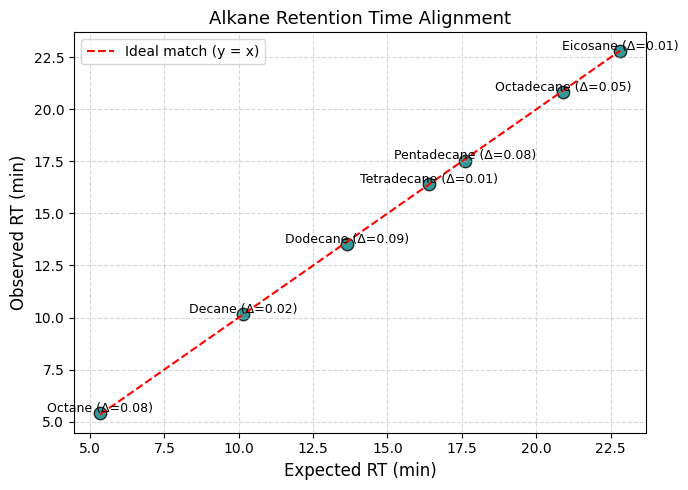

In [0]:

alkanes = pd.DataFrame([
    {"Compound": "Octane",      "tR": 5.34},
    {"Compound": "Decane",      "tR": 10.154},
    {"Compound": "Dodecane",    "tR": 13.626},
    {"Compound": "Tetradecane", "tR": 16.388},
    {"Compound": "Pentadecane", "tR": 17.62},
    {"Compound": "Octadecane",  "tR": 20.906},
    {"Compound": "Eicosane",    "tR": 22.825},
])

# Match alkanes (cleaned_qc_mixed must already exist as a pandas df)
alkane_matches = dp.match_alkanes_to_peaks(
    cleaned_data=cleaned_qc_mixed,
    alkanes_df=alkanes,
    rt_tolerance=0.1
)

# Plot the results
dp.plot_alkane_matches(alkane_matches)


# QC Peak Intensities with Metadata  (by merging the master table and QC GC-MS to have injection order for further analysis)

In [0]:


import os
import pandas as pd

paths_cfg = config["paths"]

# choose one:
# master_table_path = paths_cfg["master_table"]                  # 2024 CSV
master_table_path = paths_cfg["master_table_american"]  # 2025 XLSX

assert os.path.exists(master_table_path), f" Master table not found: {master_table_path}"

ext = os.path.splitext(master_table_path)[1].lower()

if ext == ".csv":
    master_table = pd.read_csv(master_table_path)
elif ext == ".xlsx":
    master_table = pd.read_excel(master_table_path, engine="openpyxl")
elif ext == ".xls":
    master_table = pd.read_excel(master_table_path, engine="xlrd")
else:
    raise ValueError(f"Unsupported master table format: {master_table_path}")

print("Master table path:", master_table_path)
print("Master table shape:", master_table.shape)
print("Master table shape:", master_table.shape)
display(master_table.head())
master_table = master_table.rename(columns={
    "filename": "Filename",
    "sample": "Sample",
    "day": "Day",
    "injection_order": "Injection_order"
})
# ------------------------------------------------------------
# 5) Run merge
# ------------------------------------------------------------
df_qc_mixed = dp.merge_qc_peak_intensities_with_metadata(
    cleaned_qc_mixed=cleaned_qc_mixed,
    master_table=master_table
)

display(df_qc_mixed.head())
print("df_qc_mixed shape:", df_qc_mixed.shape)

# ------------------------------------------------------------
# 5) Run merge
# ------------------------------------------------------------
df_qc_mixed = dp.merge_qc_peak_intensities_with_metadata(
    cleaned_qc_mixed=cleaned_qc_mixed,
    master_table=master_table
)

display(df_qc_mixed.head())
print("df_qc_mixed shape:", df_qc_mixed.shape)


Master table path: /Volumes/bmqg/default_bronze/fatemeh/data/GCMS SWI KW 2025.xlsx
Master table shape: (174, 15)
Master table shape: (174, 15)


#,filename,sample,block,plot,sample_order,sample_date,rep,day,injection_order,blender,tenax,remark,Scan tenax,Check
2517,KW25_Blank_B1_D1_T1,Blank,null,null,null,null,1,1,1,null,436864.0,null,null,null
2518,KW25_Blank_B1_D1_T2,Blank,null,null,null,null,1,1,2,null,436865.0,null,null,null
2519,KW25_QCB_B1_D1_T1,QCB,null,null,null,null,1,1,3,null,961325.0,null,null,null
2520,KW25_QC1_B1_D1_T1,QC1,null,null,null,null,1,1,4,null,961321.0,null,null,null
2521,KW25_QC2_B1_D1_T1,QC2,null,null,null,null,1,1,5,null,961322.0,null,null,null


 Filtered QC samples found: 4 → ['QC1', 'QC2', 'QC3', 'QC4']
 Final QC dataset shape: (6480, 9)


Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
1,1.9209999999999998,40,s1 KW25_QC1_B1_D1_T1,16880,KW25_QC1_B1_D1_T1,QC1,1,4
2,1.9555,85,s1 KW25_QC1_B1_D1_T1,6191,KW25_QC1_B1_D1_T1,QC1,1,4
3,1.9935,44,s1 KW25_QC1_B1_D1_T1,288514,KW25_QC1_B1_D1_T1,QC1,1,4
4,2.0415,64,s1 KW25_QC1_B1_D1_T1,235587,KW25_QC1_B1_D1_T1,QC1,1,4
5,2.1055,157,s1 KW25_QC1_B1_D1_T1,11688,KW25_QC1_B1_D1_T1,QC1,1,4


df_qc_mixed shape: (6480, 9)
 Filtered QC samples found: 4 → ['QC1', 'QC2', 'QC3', 'QC4']
 Final QC dataset shape: (6480, 9)


Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
1,1.9209999999999998,40,s1 KW25_QC1_B1_D1_T1,16880,KW25_QC1_B1_D1_T1,QC1,1,4
2,1.9555,85,s1 KW25_QC1_B1_D1_T1,6191,KW25_QC1_B1_D1_T1,QC1,1,4
3,1.9935,44,s1 KW25_QC1_B1_D1_T1,288514,KW25_QC1_B1_D1_T1,QC1,1,4
4,2.0415,64,s1 KW25_QC1_B1_D1_T1,235587,KW25_QC1_B1_D1_T1,QC1,1,4
5,2.1055,157,s1 KW25_QC1_B1_D1_T1,11688,KW25_QC1_B1_D1_T1,QC1,1,4


df_qc_mixed shape: (6480, 9)


# Check QC1–QC4 linearity per day

In [0]:

# --- run
results_df_mix = dp.analyze_qc_intensity_stability(
    alkane_matches=alkane_matches,
    df_qc_mixed=df_qc_mixed
)

# --- make sure R2 is numeric
results_df_mix["R2"] = pd.to_numeric(results_df_mix["R2"], errors="coerce")

# Define threshold for R2
r2_threshold = 0.9

# Keep only stable alkanes
stable_peaks = results_df_mix.loc[results_df_mix["R2"] >= r2_threshold].copy()

# Sort
stable_peaks = stable_peaks.sort_values(["Day", "Compound"])

# Print summary
cols_to_show = [c for c in ["Day","Compound","Peak","tR_best","m/z","R2"] if c in stable_peaks.columns]
print(stable_peaks[cols_to_show])

# Unique stable peaks
stable_peak_ids = sorted(pd.unique(stable_peaks["Peak"].dropna()).tolist()) if "Peak" in stable_peaks.columns else []
print("stable peaks:", stable_peak_ids)


 QC stability analysis complete: 35 regression models fitted.
Mean R² across all models: 0.816
    Day     Compound  Peak  tR_best  m/z        R2
30    1     Eicosane   310  22.8185   57  0.933080
25    1   Octadecane   263  20.8510   57  0.919952
6     2       Decane   108  10.0440   57  0.940948
31    2     Eicosane   310  22.8185   57  0.941459
26    2   Octadecane   263  20.8510   57  0.926967
21    2  Pentadecane   206  17.4910   57  0.901909
32    3     Eicosane   310  22.8185   57  0.937584
27    3   Octadecane   263  20.8510   57  0.924306
8     4       Decane   108  10.0440   57  0.919564
33    4     Eicosane   310  22.8185   57  0.931049
28    4   Octadecane   263  20.8510   57  0.934606
34    5     Eicosane   310  22.8185   57  0.940099
29    5   Octadecane   263  20.8510   57  0.924473
stable peaks: [108, 206, 263, 310]


# Visualize QC Injection Stability Using LOESS Smoothing

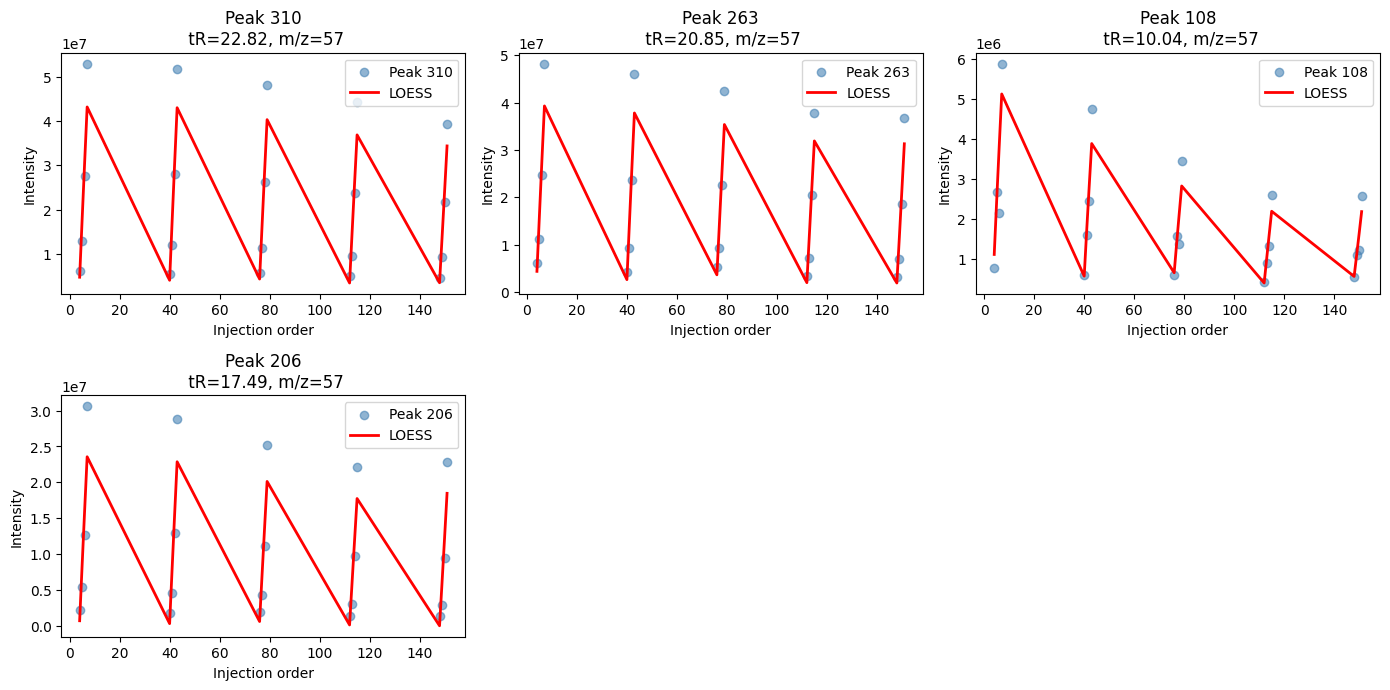

In [0]:

dp.plot_injection_stability_loess(df_qc_mixed, stable_peaks, frac=0.3) 

# Plot QC Injection Stability Using Linear Regression

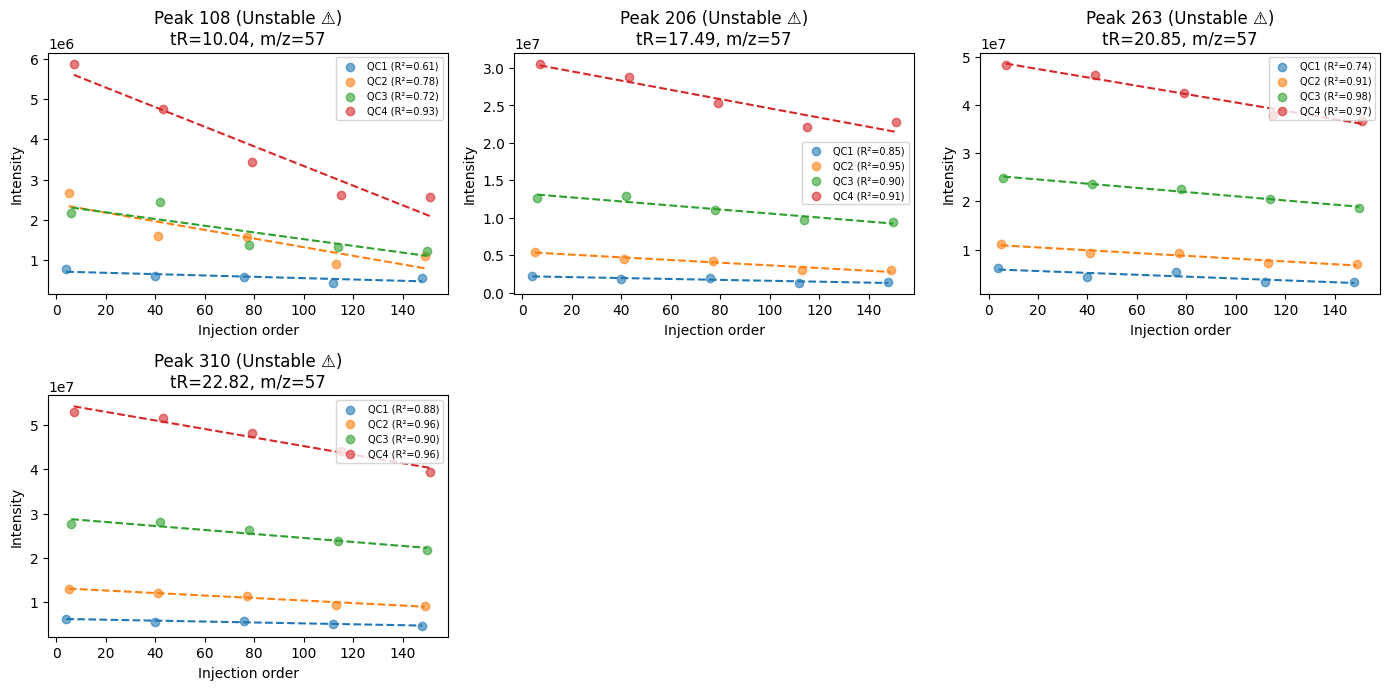

In [0]:

import seaborn as sns
# --- Plot QC Injection Stability Using Linear Regression ---
stable_peaks = [108, 206, 263, 310]

# Call the function
dp.plot_qc_injection_stability_linear(
    df_qc_mixed=df_qc_mixed,  
    stable_peaks=stable_peaks, # list of peak IDs
    qc_levels=["QC1", "QC2", "QC3", "QC4"],  
    max_plots=9                # number of plots per figure
)


# Drift correction

Output dir ready: /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american
Stable peaks : [108, 206, 263, 310]
 Removing accidental 'Intensity' column from wide QC table
Alkane QC shape: (80, 10)


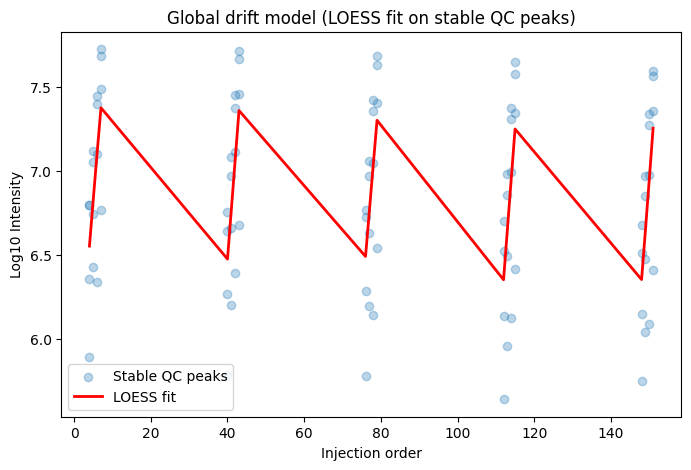

 QC drift correction applied (80 rows)
 Sample drift correction applied (20 samples)


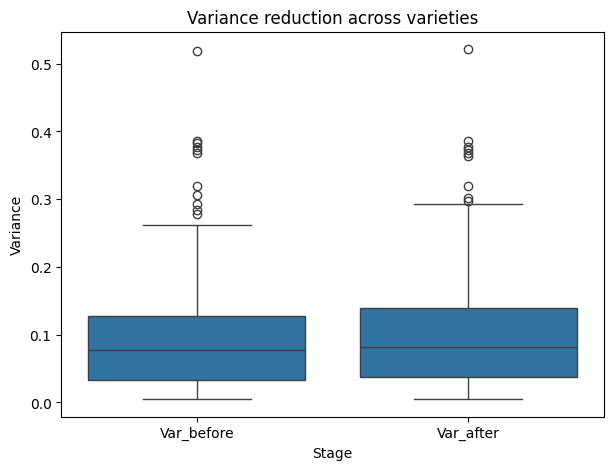

 Results saved to /Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american
 Global drift correction complete.

 QC drift correction completed
Corrected QC shape : (324, 23)
QC eval shape     : (4, 3)
Sample eval shape : (324, 3)


Peak,tR_best,m/z,s1 KW25_QC1_B1_D1_T1,s10 KW25_QC2_B1_D5_T1,s11 KW25_QC3_B1_D1_T1,s12 KW25_QC3_B1_D2_T1,s13 KW25_QC3_B1_D3_T1,s14 KW25_QC3_B1_D4_T1,s15 KW25_QC3_B1_D5_T1,s16 KW25_QC4_B1_D1_T1,s17 KW25_QC4_B1_D2_T1,s18 KW25_QC4_B1_D3_T1,s19 KW25_QC4_B1_D4_T1,s2 KW25_QC1_B1_D2_T1,s20 KW25_QC4_B1_D5_T1,s3 KW25_QC1_B1_D3_T1,s4 KW25_QC1_B1_D4_T1,s5 KW25_QC1_B1_D5_T1,s6 KW25_QC2_B1_D1_T1,s7 KW25_QC2_B1_D2_T1,s8 KW25_QC2_B1_D3_T1,s9 KW25_QC2_B1_D4_T1
1,1.9209999999999998,40,83084.3676407061,31839.552276217866,41969.61325936915,16530.859962932765,39760.27281292778,39940.467246502754,33484.80580016352,44594.18435709197,45236.61668548988,41624.89347339958,34848.01586286135,40943.28844205062,37331.565229960324,41037.30292913323,34840.1813222712,33061.74060829175,16530.859962932765,16530.859962932765,38146.35745134294,16530.859962932765
2,1.9555,85,30474.955004517087,8589.573757173534,14613.356153477032,28526.52092412958,6591.765906668059,31745.53778913527,55568.4170888392,13756.45327642199,11535.361019095333,4596.896008883917,17695.268558153864,6816.029631063036,47506.67482150534,4374.590919636494,6722.994461554201,6267.611789747808,13253.084043500523,6082.520768303915,4657.613698458105,4786.883618196694
3,1.9935,44,1420020.020369548,520529.7940843487,919673.19558144,1126697.0134076423,664004.7152305753,1004999.1771494986,1157772.718658742,1036037.6683327942,774891.8647917943,529801.9728728707,804071.6112200586,653102.9519992877,940216.3403265647,571428.8456638446,530455.1776945802,590404.1029733513,317598.5443989599,595420.1675862374,279839.9760244064,535469.2836723195
4,2.0415,64,1159522.4637603634,176936.22332462037,179231.74371755405,268254.649126622,162981.92721586916,147586.07563851803,221765.4645818453,287588.33666813147,221520.63518840086,129573.48750403404,166598.54701582837,206083.65227295115,285402.49984346103,171608.73572327255,138123.90924068267,181444.0221167167,258883.5592631485,217663.10326529262,157235.2916929445,115061.95969580376
5,2.1055,157,30195.94617226219,14925.758459511966,19439.433157051037,66430.02829960207,7069.672882671325,19682.3039153478,17330.962420708744,27826.308858878943,10213.282294496117,19038.892269376185,17269.26541356077,10574.650479219905,104825.15309711074,8134.191085367132,11374.75293699587,12777.13570264481,103740.06922536543,18098.747398550066,40384.09810742388,6608.414305422268


Peak,R2_before,R2_after
108,0.11800609646439064,0.17807410621172992
206,0.01803560138650051,0.001017676762823494
263,0.021670804569274726,9.261764429835395E-7
310,0.01154103163304887,0.15474610762590701


In [0]:
import os

out_dir = "/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american"
os.makedirs(out_dir, exist_ok=True)

print("Output dir ready:", out_dir)



# =========================================================
# 1) READ FROM CONFIG
# =========================================================

params = config.get("parameters", {})
stable_peaks = params.get("stable_peaks", [108, 206, 263, 310])
loess_frac   = params.get("loess_frac", 0.3)
loess_delta  = params.get("loess_delta", 0.0)

print("Stable peaks :", stable_peaks)


# =========================================================
# 2)  CRITICAL FIX — REMOVE WRONG Intensity COLUMN
# =========================================================

if "Intensity" in cleaned_qc_mixed.columns:
    print(" Removing accidental 'Intensity' column from wide QC table")
    cleaned_qc_mixed = cleaned_qc_mixed.drop(columns=["Intensity"])

# sanity check
assert "Intensity" not in cleaned_qc_mixed.columns, " Intensity column still exists!"

# =========================================================
# 3) FILTER QC DATA FOR STABLE PEAKS
# =========================================================

alkane_qc = (
    df_qc_mixed
    .loc[df_qc_mixed["Peak"].isin(stable_peaks)]
    .copy()
)

# make sure intensity exists here (long-format QC)
assert "Intensity" in alkane_qc.columns, "alkane_qc must contain Intensity"

alkane_qc["Log_Intensity"] = np.log10(
    alkane_qc["Intensity"].astype(float) + 1
)

print("Alkane QC shape:", alkane_qc.shape)

# =========================================================
# 4) GLOBAL DRIFT CORRECTION (MODULE FUNCTION)
# =========================================================

df_corrected, alkan_qc_corrected, qc_eval_df, sample_eval_df = (
    dp.global_drift_correction(
        alkan_qc=alkane_qc,
        cleaned_df_mix=cleaned_qc_mixed,
        stable_peaks=stable_peaks,
        frac=loess_frac,
        delta=loess_delta,
        plot=True,
        save_path="/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_american"
    )
)

# =========================================================
# 5) FINAL CHECKS
# =========================================================

print("\n QC drift correction completed")
print("Corrected QC shape :", df_corrected.shape)
print("QC eval shape     :", qc_eval_df.shape)
print("Sample eval shape :", sample_eval_df.shape)

display(df_corrected.head())
display(qc_eval_df.head())


# Rank QC  Based on Corrected Intensities 

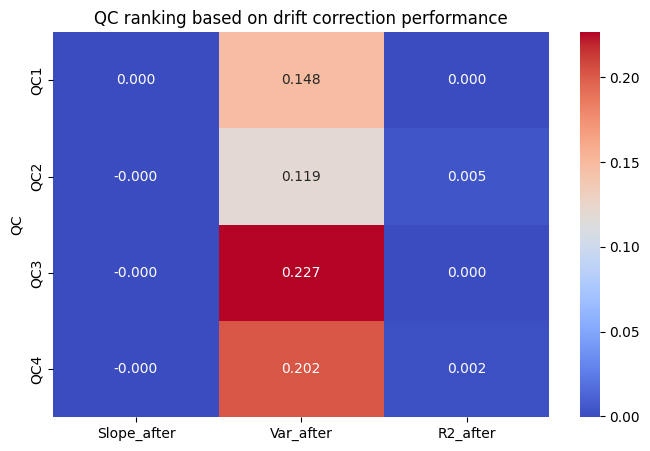

 QC ranking complete.
    QC  Var_before  Var_after  ...   ΔVar(%)    ΔR²(%)     Score
0  QC1    0.153308   0.147520  ...  3.775172 -3.056127  0.617880
1  QC2    0.128229   0.119384  ...  6.897543 -6.249739  0.178630
2  QC3    0.230193   0.226554  ...  1.580989 -1.636415 -0.061025
3  QC4    0.206630   0.201926  ...  2.276522 -2.200481 -0.325003

[4 rows x 10 columns]


In [0]:


# --- Run QC ranking ---
qc_ranking = dp.rank_qcs(alkane_qc, alkan_qc_corrected)
print(qc_ranking)


# Normalization

 QC4 medians computed for 4 peaks
 Global QC4 median intensity = 12424731.5509
 'Sample' column not found — added default value 'AllSamples'.
 Long-format data created: (6480, 6)
 Filled 6400 missing QC4 medians using global QC4 median.
 Normalization by QC4 completed (for averaged varieties).


/Workspace/Users/fatemeh.monfared@hzpc.com/aroma_flavor_project/final_flavor_project/data_prepration.py:1160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melt, x="Stage", y="Log10 Intensity", palette=["#4c72b0", "#dd8452"])


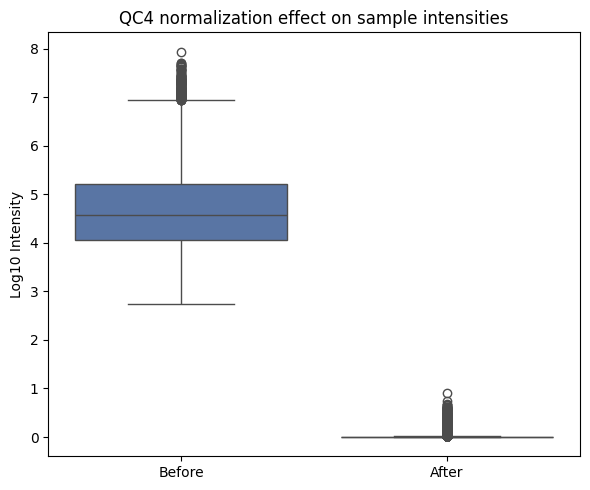

 Boxplot comparison (Before vs After) generated successfully.


In [0]:
from sklearn.linear_model import LinearRegression


df_normalized_wide, df_normalized_long = dp.normalize_with_qc4_meaned_samples(
    df_corrected=df_corrected,
    alkan_qc_corrected=alkan_qc_corrected
)
